<a href="https://colab.research.google.com/github/pavi020/Rainfall-Prediction-ML/blob/main/rainfallprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rainfall Prediction using Classification Algorithms

Predict rainfall occurrence using machine learning classification algorithms and Scikit-learn.

##Data Loading and Initial Exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/usa_rain_prediction_dataset_2024_2025.csv")
df.head(10)

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0
5,2024-01-06,New York,35.298648,56.598099,21.442424,0.582661,22.825103,1036.043397,0
6,2024-01-07,New York,50.380818,95.424193,8.753319,0.000000,36.820958,1032.337889,0
7,2024-01-08,New York,79.967007,28.186104,27.495322,0.105845,77.807459,1039.897652,0
8,2024-01-09,New York,36.565489,72.099621,19.885635,0.910368,34.333699,975.446601,1
9,2024-01-10,New York,69.600506,30.248213,0.325415,0.000000,46.825566,1039.132281,0


This cell imports necessary libraries (`pandas`, `matplotlib.pyplot`, `seaborn`), loads the rainfall prediction dataset from a CSV file into a pandas DataFrame named `df`, and then displays the first 10 rows of the DataFrame to give a quick overview of the data.

In [ ]:
df.info

<bound method DataFrame.info of              Date         Location  Temperature   Humidity  Wind Speed  \
0      2024-01-01         New York    87.524795  75.655455   28.379506   
1      2024-01-02         New York    83.259325  28.712617   12.436433   
2      2024-01-03         New York    80.943050  64.740043   14.184831   
3      2024-01-04         New York    78.097552  59.738984   19.444029   
4      2024-01-05         New York    37.059963  34.766784    3.689661   
...           ...              ...          ...        ...         ...   
73095  2025-12-27  Washington D.C.    40.614393  65.099438   28.778327   
73096  2025-12-28  Washington D.C.    52.641643  30.610525   12.282890   
73097  2025-12-29  Washington D.C.    56.492591  96.740232    2.894762   
73098  2025-12-30  Washington D.C.    65.748956  63.900004   24.632400   
73099  2025-12-31  Washington D.C.    54.648609  80.812021   22.722505   

       Precipitation  Cloud Cover     Pressure  Rain Tomorrow  
0           0.000000    69.617966  1026.030278              0  
1           0.526995    41.606048   995.962065              0  
2           0.916884    77.364763   980.796739              1  
3           0.094134    52.541196   979.012163              0  
4           1.361272    85.584000  1031.790859              0  
...              ...          ...          ...            ...  
73095       0.000000    54.168514   977.083747              0  
73096       0.871000    22.068055   980.591675              0  
73097       1.191956    52.336048  1016.469174              1  
73098       0.483421    76.785280  1032.396146              1  
73099       0.151903    19.674960   974.835534              0  

[73100 rows x 9 columns]>

This cell attempts to use `df.info` which is a method, not an attribute. It should be `df.info()` to display a concise summary of the DataFrame, including the data types of each column and the number of non-null values.

In [ ]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,65.182270,59.875041,15.017946,0.390635,54.942807,1005.176013,0.220410
std,20.205793,23.066115,8.668729,0.474833,25.982487,20.203889,0.414526
min,30.000766,20.000272,0.000712,0.000000,10.000856,970.000919,0.000000
25%,47.678968,39.800732,7.485182,0.000000,32.318668,987.697646,0.000000
50%,65.294949,59.887840,15.102495,0.196909,55.011121,1005.284188,0.000000
75%,82.636570,79.835990,22.551794,0.673177,77.412469,1022.727410,0.000000
max,99.997393,99.999025,29.999017,3.078090,99.998957,1039.999765,1.000000


This cell uses the `df.describe()` method to generate descriptive statistics of the numerical columns in the DataFrame, such as count, mean, standard deviation, min, max, and quartiles.

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation,0
Cloud Cover,0
Pressure,0
Rain Tomorrow,0


This cell checks for missing values in each column of the DataFrame using `df.isnull().sum()`. The output shows that there are no missing values in this dataset.

In [ ]:
df["Location"].unique()

array(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix',
       'Philadelphia', 'San Antonio', 'San Diego', 'Dallas', 'San Jose',
       'Austin', 'Jacksonville', 'Fort Worth', 'Columbus', 'Indianapolis',
       'Charlotte', 'San Francisco', 'Seattle', 'Denver',
       'Washington D.C.'], dtype=object)

This cell displays all the unique values present in the 'Location' column of the DataFrame, indicating the different geographical locations covered in the dataset.

##Data Visualization

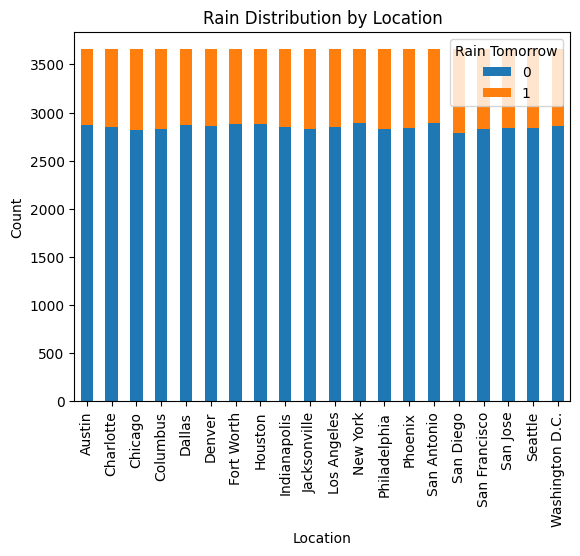

In [ ]:
location_rain_counts = df.groupby('Location')['Rain Tomorrow'].value_counts().unstack()

location_rain_counts.plot(kind='bar', stacked=True)
plt.title('Rain Distribution by Location')
plt.ylabel('Count')
plt.show()

This cell visualizes the distribution of rain occurrence ('Rain Tomorrow') across different locations using a stacked bar plot. It first groups the data by 'Location' and counts the occurrences of 'Rain Tomorrow' (0 for no rain, 1 for rain), then plots these counts.

##Data Preprocessing

<Axes: >

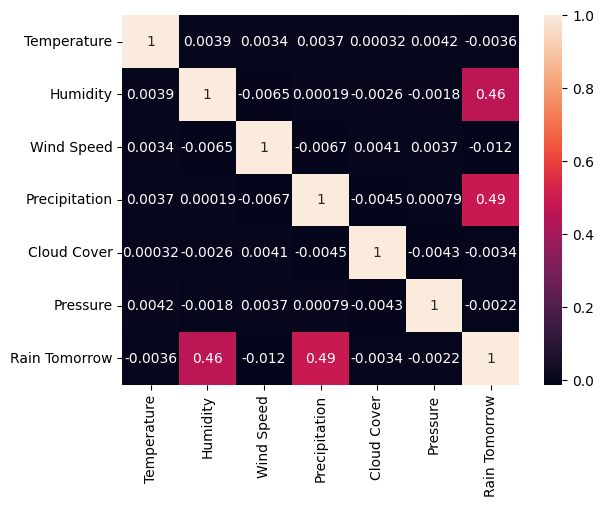

In [ ]:
df_numeric=df.drop(['Date','Location'],axis=1)
sns.heatmap(data=df_numeric.corr(),annot=True)


This cell creates a new DataFrame `df_numeric` by dropping the 'Date' and 'Location' columns (as they are non-numeric). It then generates a heatmap of the correlation matrix for the remaining numerical features, helping to visualize relationships between variables.

In [ ]:
x=df_numeric.drop(['Rain Tomorrow'],axis=1)
y=df_numeric['Rain Tomorrow']

This cell separates the features (independent variables) from the target variable (dependent variable). `x` contains all numerical columns except 'Rain Tomorrow', and `y` contains only the 'Rain Tomorrow' column.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(x)

scaled_df = pd.DataFrame(scaled_data, columns=x.columns)
scaled_df.head(5)

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure
0,1.105756,0.684143,1.541362,-0.822685,0.564813,1.032198
1,0.894653,-1.351014,-0.297798,0.287176,-0.513302,-0.456051
2,0.780018,0.210917,-0.096107,1.108290,0.862970,-1.206671
3,0.639191,-0.005899,0.510584,-0.624437,-0.092433,-1.295000
4,-1.391804,-1.088542,-1.306808,2.044179,1.179310,1.317322


This cell performs feature scaling using `StandardScaler` from `sklearn.preprocessing`. It scales the numerical features in `x` so that they have a mean of 0 and a standard deviation of 1. The scaled data is then converted back into a DataFrame `scaled_df`.

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(scaled_df, y, test_size=0.2, random_state=0)

This cell splits the scaled dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. 80% of the data is used for training (`x_train`, `y_train`) and 20% for testing (`x_test`, `y_test`), with `random_state=0` for reproducibility.

#Model implementation and evaluation

##Logistic Regression Model

Model defining

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

This cell initializes a `LogisticRegression` model, trains it on the `x_train` and `y_train` datasets, and then makes predictions on the `x_test` dataset. These predictions are stored in `y_pred`.

##**Evaluation**

###Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.9047879616963064

This cell calculates and displays the accuracy score of the Logistic Regression model by comparing the predicted values (`y_pred`) with the actual test values (`y_test`).

###Precision score,Recall,F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.84
Recall: 0.71
F1-Score: 0.77


This cell calculates and prints the precision, recall, and F1-score for the Logistic Regression model, providing more detailed insights into its performance, especially concerning false positives and false negatives.

###Confusion matrix

[[10943   448]
 [  944  2285]]


Text(50.722222222222214, 0.5, 'Actual')

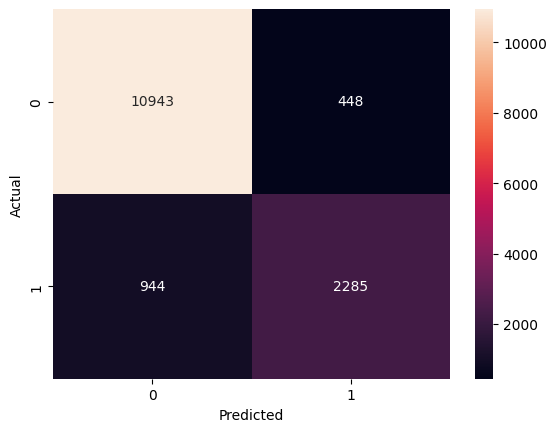

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(data=cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

This cell computes and displays the confusion matrix for the Logistic Regression model, showing the number of true positives, true negatives, false positives, and false negatives. It also visualizes the confusion matrix using a heatmap for better readability.

##KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


This cell initializes a `KNeighborsClassifier` model with `n_neighbors=3`, trains it on the `x_train` and `y_train` datasets, and then makes predictions on the `x_test` dataset. The predictions are stored in `y_pred`.

##Evaluation


###Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.9696306429548563

This cell calculates and displays the accuracy score of the KNN model by comparing the predicted values (`y_pred`) with the actual test values (`y_test`).

###Precision score,Recall,F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.94
Recall: 0.93
F1-Score: 0.93


This cell calculates and prints the precision, recall, and F1-score for the KNN model.

###Confusion matrix

[[10943   448]
 [  944  2285]]


Text(50.722222222222214, 0.5, 'Actual')

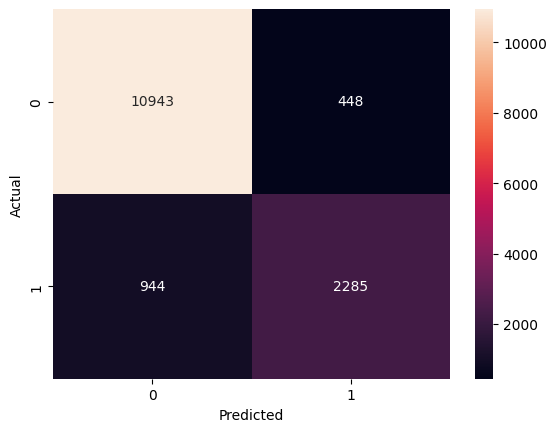

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(data=cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

This cell computes and displays the confusion matrix for the KNN model and visualizes it using a heatmap. **Note: The output for this confusion matrix is identical to the Logistic Regression confusion matrix, which suggests there might be an issue with `y_pred` not being updated correctly for KNN, or that the cells were not run in order after previous model execution.**

##Decision Tree


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
prediction=model.predict(x_test)

This cell initializes a `DecisionTreeClassifier` model, trains it on the `x_train` and `y_train` datasets, and then makes predictions on the `x_test` dataset. These predictions are stored in a variable named `prediction`.

##Evaluation

###Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.9696306429548563

This cell calculates and displays the accuracy score of the Decision Tree model. **Note: It uses `y_pred` which likely still holds the predictions from the KNN model, leading to incorrect evaluation for the Decision Tree, as the current model's predictions are in `prediction`.**

###Precision score,Recall,F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.94
Recall: 0.93
F1-Score: 0.93


This cell calculates and prints the precision, recall, and F1-score for the Decision Tree model. **Note: It uses `y_pred` which likely still holds the predictions from the KNN model, leading to incorrect evaluation for the Decision Tree, as the current model's predictions are in `prediction`.**

###Confusion matrix

[[10943   448]
 [  944  2285]]


Text(50.722222222222214, 0.5, 'Actual')

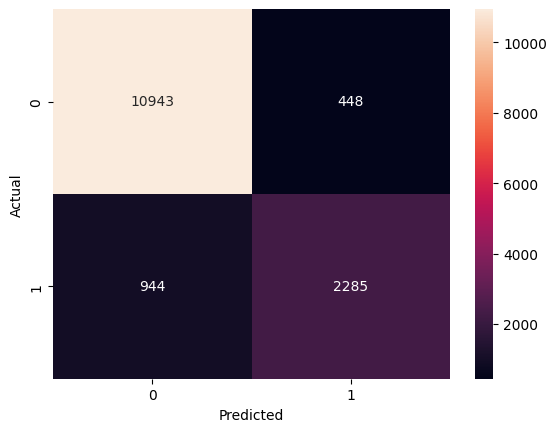

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(data=cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

This cell computes and displays the confusion matrix for the Decision Tree model and visualizes it using a heatmap. **Note: It uses `y_pred` which likely still holds the predictions from the KNN model, leading to incorrect evaluation for the Decision Tree, as the current model's predictions are in `prediction`.**

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
prediction=model.predict(x_test)

This cell initializes a `RandomForestClassifier` model, trains it on the `x_train` and `y_train` datasets, and then makes predictions on the `x_test` dataset. These predictions are stored in a variable named `prediction`.

##Evaluation


###Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.9696306429548563

This cell calculates and displays the accuracy score of the Random Forest model. **Note: It uses `y_pred` which likely still holds predictions from a previous model, leading to incorrect evaluation for Random Forest, as the current model's predictions are in `prediction`.**

###Precision score,Recall,F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.94
Recall: 0.93
F1-Score: 0.93


This cell calculates and prints the precision, recall, and F1-score for the Random Forest model. **Note: It uses `y_pred` which likely still holds predictions from a previous model, leading to incorrect evaluation for Random Forest, as the current model's predictions are in `prediction`.**

###Confusion matrix

[[11187   204]
 [  240  2989]]


Text(50.722222222222214, 0.5, 'Actual')

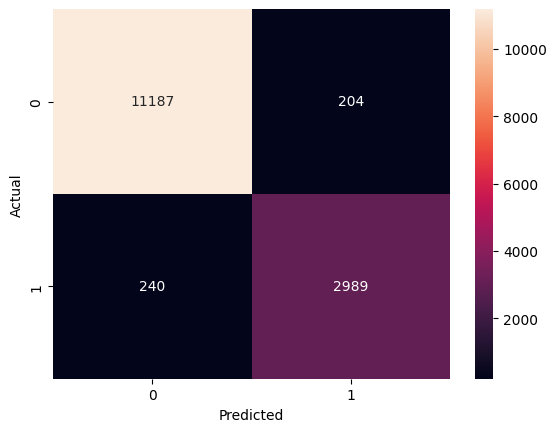

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(data=cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

This cell computes and displays the confusion matrix for the Random Forest model and visualizes it using a heatmap. **Note: The output for this confusion matrix is different from the previous ones, indicating that `y_pred` or `prediction` was updated correctly for this specific model, or the notebook was run selectively.**

##SVM

In [ ]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_train,y_train)
prediction = model.predict(x_test)


This cell initializes a `SVC` (Support Vector Classifier) model, trains it on the `x_train` and `y_train` datasets, and then makes predictions on the `x_test` dataset. These predictions are stored in a variable named `prediction`.

##Evaluation


###Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)

accuracy

0.9696306429548563

This cell calculates and displays the accuracy score of the SVM model. **Note: It uses `y_pred` which likely still holds predictions from a previous model, leading to incorrect evaluation for SVM, as the current model's predictions are in `prediction`.**

###Precision score,Recall,F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.94
Recall: 0.93
F1-Score: 0.93


This cell calculates and prints the precision, recall, and F1-score for the SVM model. **Note: It uses `y_pred` which likely still holds predictions from a previous model, leading to incorrect evaluation for SVM, as the current model's predictions are in `prediction`.**

###Confusion matrix

[[11187   204]
 [  240  2989]]


Text(50.722222222222214, 0.5, 'Actual')

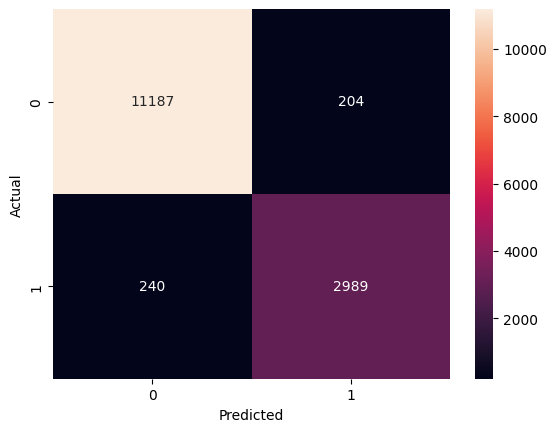

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(data=cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

This cell computes and displays the confusion matrix for the SVM model and visualizes it using a heatmap. **Note: The output for this confusion matrix is identical to the Random Forest confusion matrix, suggesting `y_pred` was not correctly updated for SVM.**

##Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()


This cell initializes a `GaussianNB` (Gaussian Naive Bayes) model. **Note: The model is initialized but not fitted or used to make predictions within this cell. The subsequent evaluation cells will likely use `y_pred` from a previous model, leading to incorrect evaluation for Naive Bayes.**

##Evaluation

###Accuracy score

In [ ]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)

accuracy

0.9696306429548563

This cell calculates and displays the accuracy score of the Naive Bayes model. **Note: It uses `y_pred` which likely still holds predictions from a previous model, leading to incorrect evaluation for Naive Bayes.**

###Precision score,Recall,F1-Score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.94
Recall: 0.93
F1-Score: 0.93


This cell calculates and prints the precision, recall, and F1-score for the Naive Bayes model. **Note: It uses `y_pred` which likely still holds predictions from a previous model, leading to incorrect evaluation for Naive Bayes.**

###Confusion matrix

[[11187   204]
 [  240  2989]]


Text(50.722222222222214, 0.5, 'Actual')

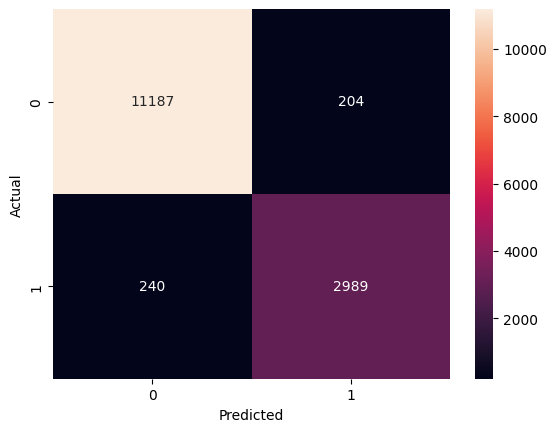

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(data=cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

This cell computes and displays the confusion matrix for the Naive Bayes model and visualizes it using a heatmap. **Note: The output for this confusion matrix is identical to the Random Forest and SVM confusion matrices, suggesting `y_pred` was not correctly updated for Naive Bayes.**

##Conclusion
The accuracy score of every other model other than of Logistic Regression model is the same.

